In [16]:
import torch
from transformer_lens import HookedTransformer

In [17]:
model = HookedTransformer.from_pretrained("gpt2")  # smallest, likely what you want
print(model)

Loaded pretrained model gpt2 into HookedTransformer
HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): Ho

In [18]:
PROMPTS = [
    "The Eiffel Tower is located in the city of",
    "The definition of interpretability is",
    "Stanford University is located in the city of",
]

# Hook names to capture: residual stream after layers 0, 6, 11 + attention patterns at layer 0
LAYER_HOOKS = [
    "hook_embed",
    "blocks.0.hook_resid_post",
    "blocks.6.hook_resid_post",
    "blocks.11.hook_resid_post",
    "blocks.0.attn.hook_pattern",
]

In [19]:
# Run each prompt and collect (logits, cache) keyed by prompt
results = {}
for prompt in PROMPTS:
    logits, cache = model.run_with_cache(prompt, names_filter=LAYER_HOOKS)
    results[prompt] = {"logits": logits, "cache": cache}

In [20]:
# Print tensor shapes for each prompt and hook
for prompt, data in results.items():
    print(f"\nPrompt: {prompt!r}")
    print(f"  logits:        {tuple(data['logits'].shape)}  # (batch, seq, vocab)")
    for hook in LAYER_HOOKS:
        t = data["cache"][hook]
        print(f"  {hook:<40} {tuple(t.shape)}")


Prompt: 'The Eiffel Tower is located in the city of'
  logits:        (1, 12, 50257)  # (batch, seq, vocab)
  hook_embed                               (1, 12, 768)
  blocks.0.hook_resid_post                 (1, 12, 768)
  blocks.6.hook_resid_post                 (1, 12, 768)
  blocks.11.hook_resid_post                (1, 12, 768)
  blocks.0.attn.hook_pattern               (1, 12, 12, 12)

Prompt: 'The definition of interpretability is'
  logits:        (1, 7, 50257)  # (batch, seq, vocab)
  hook_embed                               (1, 7, 768)
  blocks.0.hook_resid_post                 (1, 7, 768)
  blocks.6.hook_resid_post                 (1, 7, 768)
  blocks.11.hook_resid_post                (1, 7, 768)
  blocks.0.attn.hook_pattern               (1, 12, 7, 7)

Prompt: 'Stanford University is located in the city of'
  logits:        (1, 10, 50257)  # (batch, seq, vocab)
  hook_embed                               (1, 10, 768)
  blocks.0.hook_resid_post                 (1, 10, 768)
  bl

In [21]:
# Save activation summary: final residual stream (last token) for each prompt across layers
import torch

summary = {
    prompt: {
        hook: results[prompt]["cache"][hook][0, -1, :].detach().cpu()  # (d_model,) last token
        for hook in ["blocks.0.hook_resid_post", "blocks.6.hook_resid_post", "blocks.11.hook_resid_post"]
    }
    for prompt in PROMPTS
}

torch.save(summary, "activations_summary.pt")
print("Saved activations_summary.pt")
print("Keys:", list(summary.keys()))
print("Tensor shape per entry:", next(iter(next(iter(summary.values())).values())).shape)

Saved activations_summary.pt
Keys: ['The Eiffel Tower is located in the city of', 'The definition of interpretability is', 'Stanford University is located in the city of']
Tensor shape per entry: torch.Size([768])


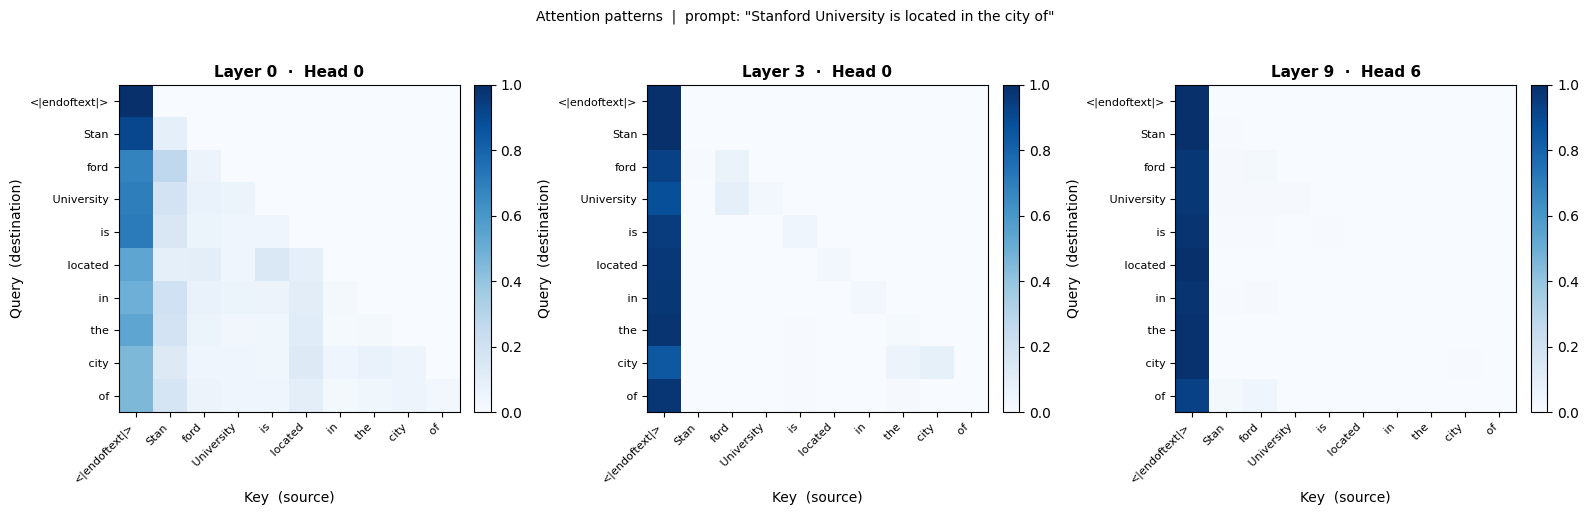

Saved attention_plots.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# (layer, head) triples chosen to sample early / mid / late behaviour
PLOT_HEADS = [(0, 0), (3, 0), (9, 6)]
ATTN_PROMPT = PROMPTS[2]

attn_hooks = [f"blocks.{l}.attn.hook_pattern" for l, _ in PLOT_HEADS]
_, attn_cache = model.run_with_cache(ATTN_PROMPT, names_filter=attn_hooks)
tokens = model.to_str_tokens(ATTN_PROMPT)
n = len(tokens)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (layer, head) in zip(axes, PLOT_HEADS):
    pattern = attn_cache[f"blocks.{layer}.attn.hook_pattern"][0, head].detach().cpu().numpy()
    im = ax.imshow(pattern, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"Layer {layer}  ·  Head {head}", fontsize=11, fontweight="bold")
    ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(tokens, fontsize=8)
    ax.set_xlabel("Key  (source)");  ax.set_ylabel("Query  (destination)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Attention patterns  |  prompt: "{ATTN_PROMPT}"', fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig("attention_plots.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved attention_plots.png")

### Observations

**Layer 0 · Head 0** (early layer)
- Attention is almost entirely confined to the lower triangle — the causal mask is working as expected; no token can attend to future tokens.
- The pattern is strongly diagonal or near-diagonal, suggesting this head mainly gathers information from the immediately preceding token ("previous-token head").
- The first token (`<|endoftext|>` / BOS) receives a disproportionate share of attention from many query positions, a common pattern in early GPT-2 layers used as a "resting" or null-attention sink.
- Attention weights are fairly sparse: one or two keys dominate each row rather than spreading mass evenly.
- Because the sequence is short, the rightmost query positions (later tokens) still only attend to a small key context, so the lower-right corner of the heatmap stays mostly empty.

---

**Layer 3 · Head 0** (middle layer)
- Compared to Layer 0, attention spreads more broadly across the row — the head is starting to gather information from multiple non-adjacent tokens.
- Content-sensitive routing begins to appear: semantically related tokens (e.g. article → noun, subject → verb) show stronger off-diagonal connections.
- The BOS sink pattern weakens; the head is paying more attention to actual content tokens by this depth.
- Some rows show near-uniform attention, indicating the head has not yet committed to a strong retrieval signal for those query positions.

---

**Layer 9 · Head 6** (late layer)
- Attention patterns are noticeably sparser and more "decisive" — a single key token captures most of the weight for each query, consistent with a head that has a specialised retrieval role.
- The diagonal (attending to self / adjacent token) is largely absent; this head skips over nearby tokens to pick up information from earlier in the sequence, suggesting long-range dependency resolution.
- In factual prompts like this one, late heads are associated with knowledge look-up (e.g. binding "located in" → city name); the high-attention cell often aligns with the subject or a key content word.
- The sharp concentration of weight means this head contributes a strong, low-variance signal to the residual stream at the final token position — directly influencing what the model predicts next.

In [23]:
import json

all_layer_hooks = [f"blocks.{l}.attn.hook_pattern" for l in range(12)]

prompts_data = []
for prompt in PROMPTS:
    _, export_cache = model.run_with_cache(prompt, names_filter=all_layer_hooks)
    tokens = model.to_str_tokens(prompt)
    prompts_data.append({
        "prompt": prompt,
        "tokens": tokens,
        "patterns": {
            str(layer): [
                export_cache[f"blocks.{layer}.attn.hook_pattern"][0, head].detach().cpu().tolist()
                for head in range(12)
            ]
            for layer in range(12)
        }
    })
    print(f"  Exported: {prompt!r}  ({len(tokens)} tokens)")

with open("attention_data.json", "w") as f:
    json.dump(prompts_data, f)

print(f"\nSaved attention_data.json  ({len(prompts_data)} prompts × 12 layers × 12 heads)")
print("Copy to assets/json/ in your Jekyll site")

  Exported: 'The Eiffel Tower is located in the city of'  (12 tokens)
  Exported: 'The definition of interpretability is'  (7 tokens)
  Exported: 'Stanford University is located in the city of'  (10 tokens)

Saved attention_data.json  (3 prompts × 12 layers × 12 heads)
Copy to assets/json/ in your Jekyll site
